# LAB DAY 19 — Xây dựng hệ thống **GraphRAG** với Tech Company Corpus

**Sinh viên:** Vu Duy Bao · **MSSV:** 2A202600565

Pipeline hoàn chỉnh, **chạy thật (không mock)**:

| Bước | Nội dung |
|------|----------|
| 1 | **Indexing** — trích xuất thực thể & quan hệ → bộ ba (triples) |
| 2 | **Construction** — dựng knowledge graph bằng **NetworkX** (Lựa chọn A) đã khử trùng lặp |
| 3 | **Querying** — entity-linking + duyệt BFS 2-hop + textualization |
| 4 | **Evaluation** — benchmark 20 câu hỏi: **Flat RAG vs GraphRAG** + phân tích chi phí |

> Toàn bộ phần lõi nằm trong package `graphrag/` và được dùng chung với script `graphrag_lab.py`.


## PHẦN 1 — Nghiên cứu (trả lời câu hỏi lý thuyết)

### 1.1. Entity Extraction — phân biệt **thực thể (Node)** vs **thuộc tính (attribute)**
- **Thực thể (Node):** danh từ riêng có *danh tính độc lập* và có thể là chủ thể của nhiều quan hệ — *OpenAI, Tesla, Sam Altman, General Motors*. Nếu một khái niệm còn xuất hiện ở câu/tài liệu khác và nối với thực thể khác ⇒ nó là **node**.
- **Thuộc tính (attribute):** giá trị *mô tả* một thực thể và thường **không** có quan hệ ra ngoài — năm thành lập `2015`, doanh thu, giá `$55,167`, thị phần `7.3%`. Chúng là *literal* gắn vào node hoặc edge.
- **Mẹo cho LLM:** yêu cầu LLM sinh **triple** `(subject, RELATION, object)`; nếu `object` là *con số / ngày tháng / đơn vị đo* ⇒ đó là attribute (`FOUNDED_IN 2015`); nếu `object` lại là danh từ riêng ⇒ đó là một node mới (`FOUNDED_BY Sam Altman`).

### 1.2. Vì sao **khử trùng lặp (Deduplication)** quan trọng?
- LLM/regex sinh ra nhiều **biến thể bề mặt** của cùng một thực thể: *"GM" = "General Motors"*, *"Google" = "Alphabet"*, *"Tesla Inc." = "Tesla"*.
- Nếu không gộp, mỗi biến thể thành **một node riêng** ⇒ cạnh bị **phân mảnh**, bậc (degree) của node thật bị chia nhỏ, và **duyệt đa bước (multi-hop) đứt gãy** (đi tới "GM" sẽ không thấy quan hệ gắn ở "General Motors").
- Khử trùng lặp = chuẩn hoá tên (canonicalization) + alias map ⇒ một thực thể = **một node** ⇒ đồ thị đặc hơn, truy vấn chính xác hơn. (Xem `graph_store.canonicalize`.)

### 1.3. Duyệt đồ thị **BFS** vs **tìm kiếm vector**
| | Vector search (Flat RAG) | BFS trên Graph (GraphRAG) |
|---|---|---|
| Đơn vị | đoạn văn (chunk) | thực thể & quan hệ (node/edge) |
| Cách tìm | độ tương đồng **ngữ nghĩa** với câu hỏi | đi theo **cạnh quan hệ** từ thực thể gốc |
| Đa bước | khó — phải có 1 chunk chứa **đủ** các bước | tự nhiên — mỗi hop = một cạnh |
| Điểm yếu | "lost in the middle", trộn ngữ cảnh ⇒ dễ **ảo giác** | cần **neo thực thể**; phụ thuộc chất lượng trích xuất |

→ Vector search trả về *văn bản gần nghĩa*; BFS trả về *đường đi quan hệ có cấu trúc*. GraphRAG mạnh ở câu hỏi **nối nhiều sự kiện** quanh một thực thể.


## PHẦN 2 — Environment Setup

```bash
pip install networkx numpy            # bắt buộc
pip install matplotlib scikit-learn pandas   # khuyến nghị (vẽ đồ thị, TF-IDF, CSV)
# Tuỳ chọn dùng LLM thật:
# pip install anthropic   &&  set GRAPHRAG_LLM=anthropic ; set ANTHROPIC_API_KEY=...
```

> Theo yêu cầu của lab, ta dựng đồ thị bằng **NetworkX** (Lựa chọn A) — *không* dùng Neo4j/NodeRAG.
Mọi thư viện nặng/khoá API đều **tùy chọn**: nếu thiếu, pipeline tự hạ xuống chế độ offline (TF-IDF + trích xuất heuristic) nhưng **vẫn chạy thật**.


In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath('.'))

from graphrag import (Config, load_corpus, chunk_documents, extract_triples,
                      build_graph, save_graph, draw_graph, FlatRAG, GraphRAG,
                      get_llm, TokenMeter)
from graphrag.extract import get_extractor
from graphrag.graph_store import graph_stats

cfg = Config()
meter = TokenMeter()
print(cfg.describe())
llm = get_llm(cfg, meter)
print('LLM backend (answers):', llm.backend, '|', llm.model or 'offline-extractive')

corpus_dir = C:\Users\ADMIN\Downloads\dataset\dataset
out_dir    = outputs
extractor  = heuristic
llm_backend= none
chunk_size = 900 (overlap 150)

LLM backend (answers): none | claude-haiku-4-5-20251001


## BƯỚC 1 — Trích xuất thực thể & quan hệ (Indexing)

Đọc corpus → cắt chunk → trích xuất triple `(subject, RELATION, object)`.
`HeuristicExtractor` là một **bộ trích xuất quan hệ thật** (NER theo proper-noun + gazetteer công nghệ/EV, sau đó các mẫu động từ/giới từ ánh xạ cặp thực thể sang quan hệ có kiểu: `FOUNDED_BY, ACQUIRED, CEO_OF, HEADQUARTERED_IN, ...`).

In [2]:
docs = load_corpus(cfg)
chunks = chunk_documents(docs, cfg)
print(f'Documents: {len(docs)} | Chunks: {len(chunks)}')
print('Ví dụ tài liệu:', docs[1].doc_id, '—', docs[1].title[:70])

Documents: 70 | Chunks: 1608
Ví dụ tài liệu: doc_2 — EV Sales Growth Slows; Market Leader Tesla Stalls - Cox ...


In [3]:
extractor = get_extractor(cfg, llm)
print('Extractor:', extractor.name)

t0 = time.perf_counter()
triples = extract_triples(chunks, cfg, llm)
dt = time.perf_counter() - t0
meter.add('extract', prompt=sum(len(c.text) for c in chunks)//4,
          completion=len(triples)*12, seconds=dt)
print(f'Trích xuất {len(triples)} triples trong {dt:.2f}s')
for t in triples[:10]:
    print(f'  ({t.subject})  -[{t.relation}]->  ({t.object})')

Extractor: heuristic


Trích xuất 2911 triples trong 11.62s
  (Anh Bui)  -[MENTIONED_WITH]->  (Peter Slowik)
  (Anh Bui)  -[MENTIONED_WITH]->  (Nic Lutsey Download)
  (Anh Bui)  -[MENTIONED_WITH]->  (United States)
  (United States)  -[MENTIONED_WITH]->  (ICCT)
  (Cox Automotive)  -[MENTIONED_WITH]->  (Stephanie Valdez Streaty)
  (Cox Automotive)  -[MENTIONED_WITH]->  (Industry Insights)
  (Kelley Blue Book)  -[MENTIONED_WITH]->  (Tesla)
  (Mercedes)  -[MENTIONED_WITH]->  (Cadillac)
  (Mercedes)  -[MENTIONED_WITH]->  (Vinfast)
  (Mercedes)  -[MENTIONED_WITH]->  (Hyundai)


## BƯỚC 2 — Dựng Knowledge Graph (NetworkX, đã khử trùng lặp)

`build_graph` chuẩn hoá/khử trùng lặp thực thể (canonicalize + alias) rồi tạo `MultiDiGraph`:
node = thực thể, edge = quan hệ có kiểu (kèm `weight` = số lần xuất hiện và `evidence` = câu gốc).

In [4]:
G = build_graph(triples, cfg)
stats = graph_stats(G)
print(json.dumps(stats, indent=2, ensure_ascii=False)[:600])

paths = save_graph(G, cfg.out_dir)
print('Saved:', paths['graphml'])

{
  "nodes": 1955,
  "edges": 1975,
  "relation_types": {
    "MENTIONED_WITH": 1933,
    "FOUNDED_IN": 17,
    "COMPETES_WITH": 7,
    "INVESTED_IN": 5,
    "HEADQUARTERED_IN": 5,
    "HAS_CEO": 4,
    "CEO_OF": 2,
    "ACQUIRED": 1,
    "PARTNERED_WITH": 1
  },
  "density": 0.00052
}
Saved: outputs\knowledge_graph.graphml


### Trực quan hoá đồ thị tri thức (Deliverable #2)

Saved PNG: outputs\knowledge_graph.png


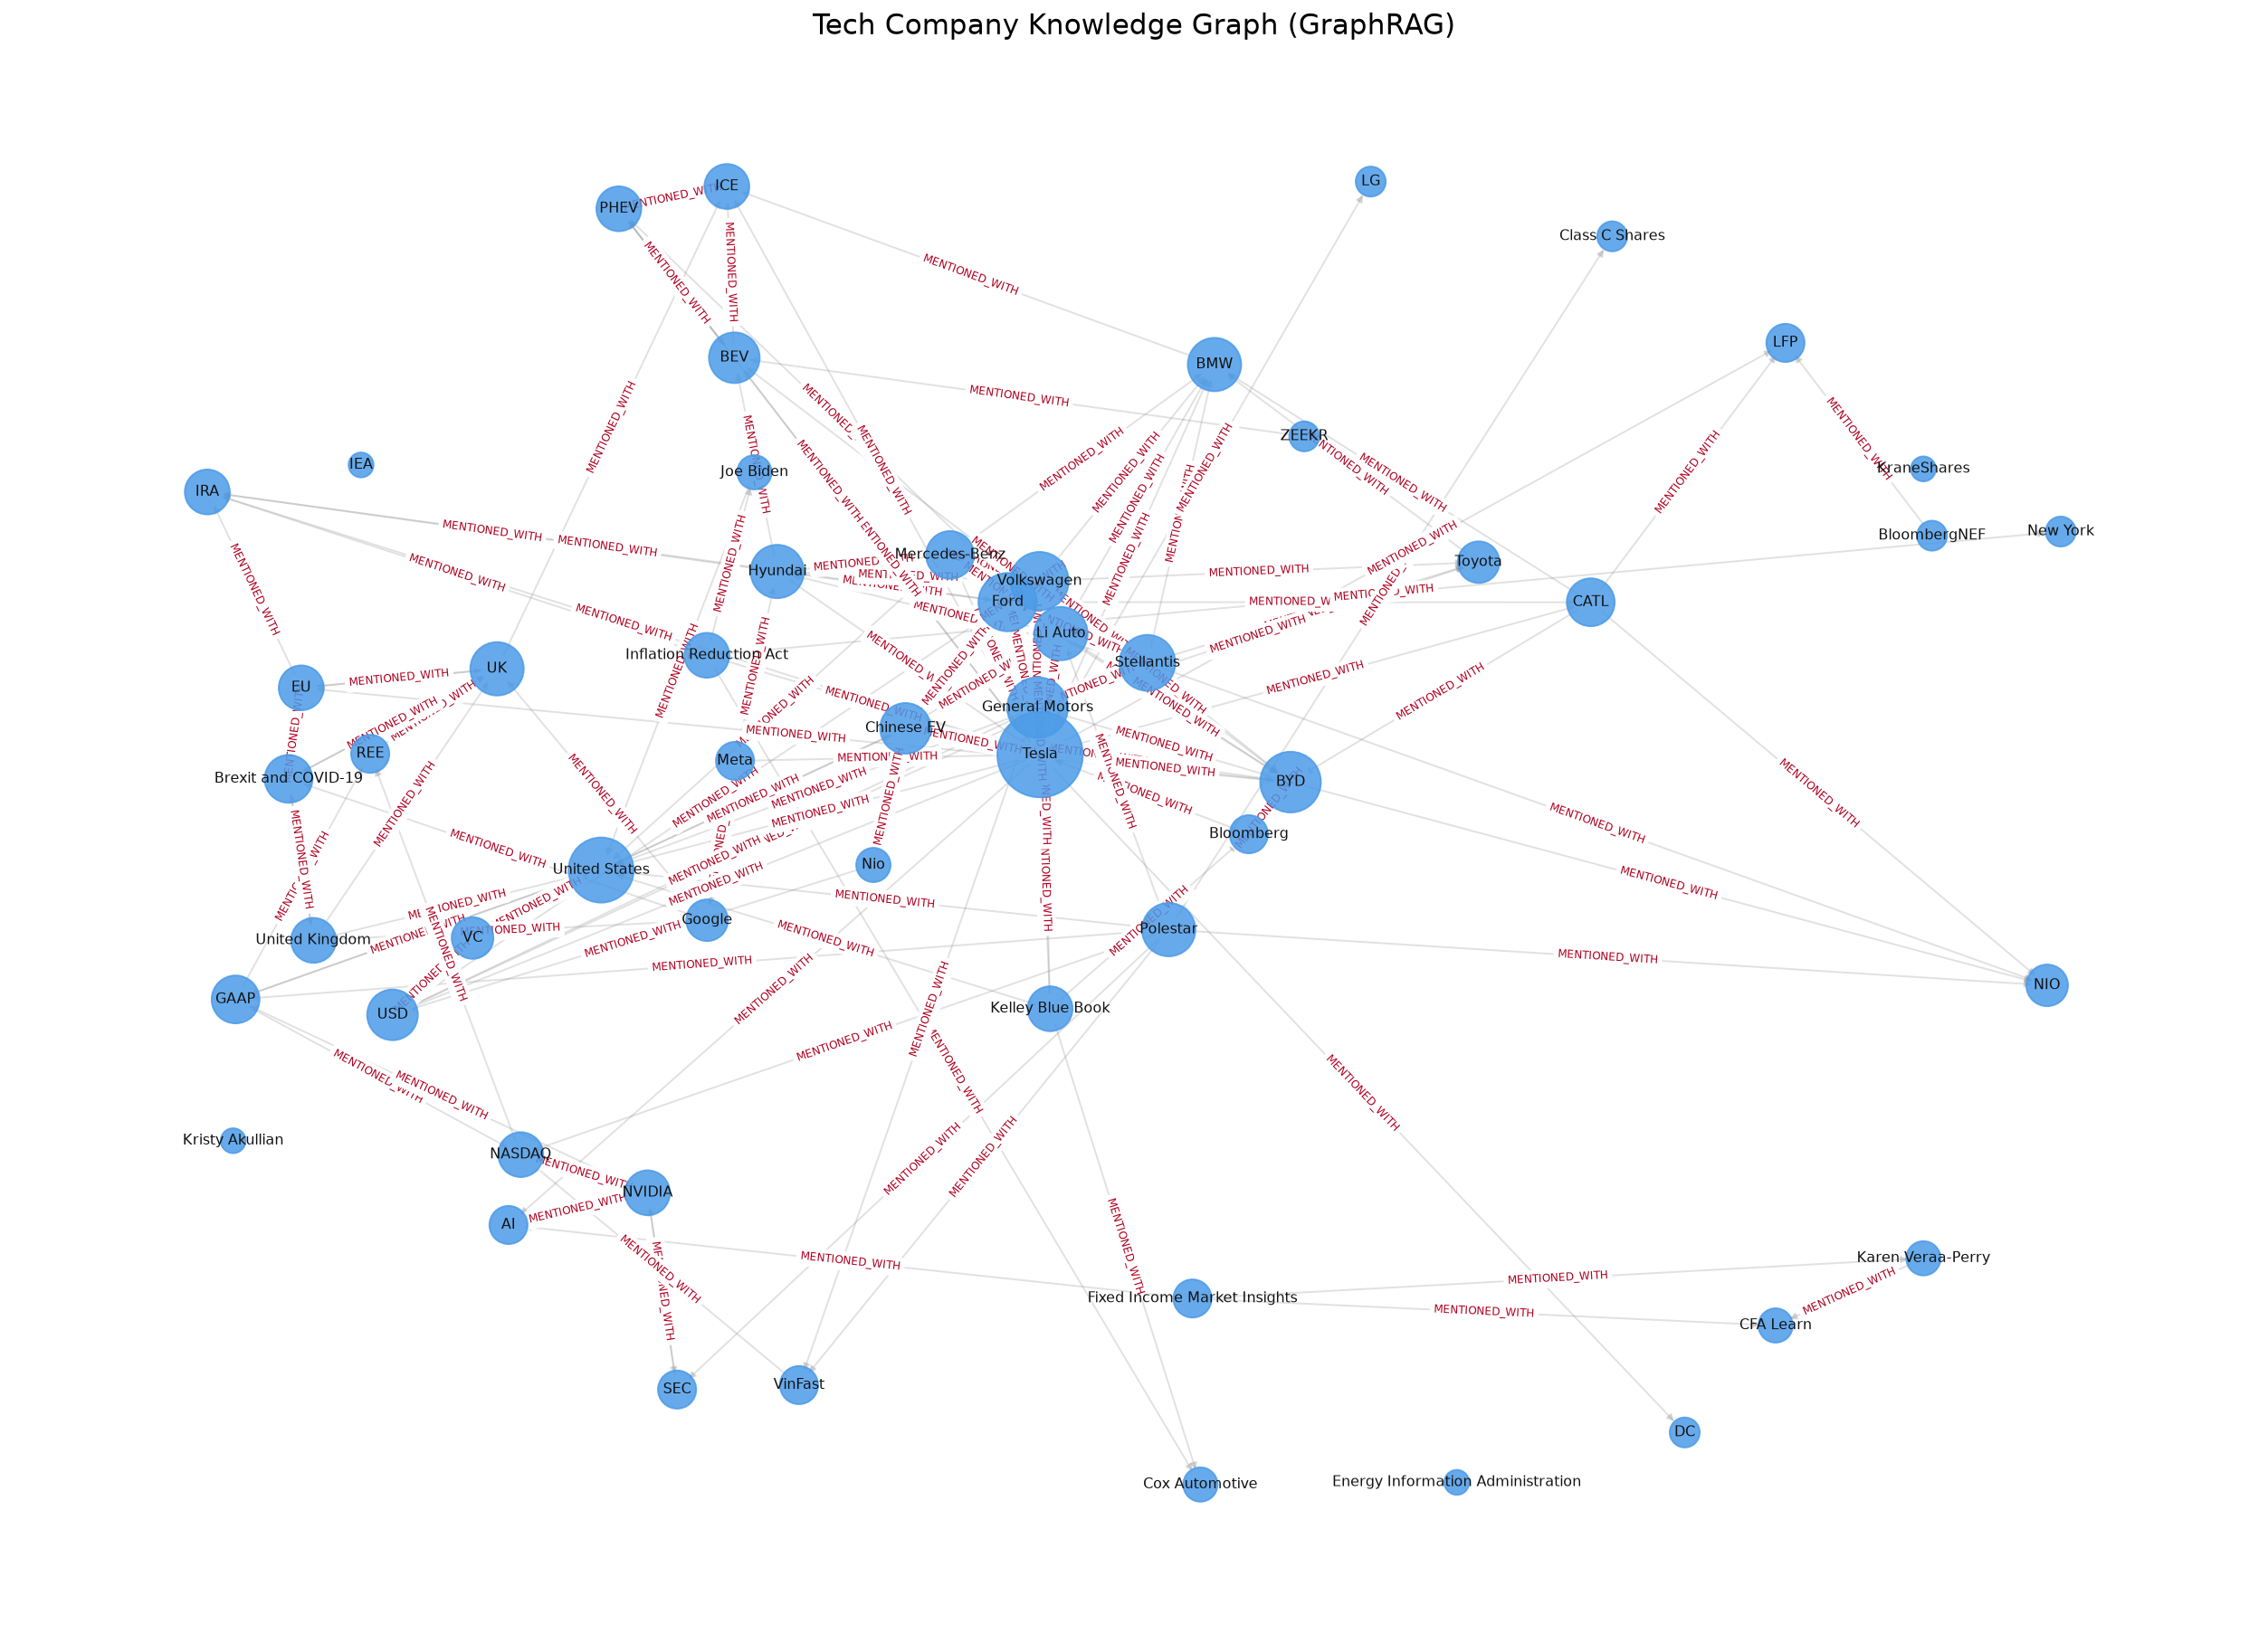

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
png = draw_graph(G, os.path.join(cfg.out_dir, 'knowledge_graph.png'), top_n=55)
print('Saved PNG:', png)
from PIL import Image
display(Image.open(png)) if png else None

## BƯỚC 3 — Truy vấn (Querying)

- **Flat RAG**: TF-IDF + cosine → lấy top-k chunk theo độ tương đồng (mô phỏng ChromaDB/FAISS).
- **GraphRAG**: trích thực thể trong câu hỏi → **link** vào node → **BFS 2-hop** → gom triple + câu evidence + **chunk nguồn theo provenance đồ thị** (rerank theo độ liên quan câu hỏi) → textualize.

In [6]:
flat = FlatRAG(cfg, llm).index(chunks)
graph = GraphRAG(G, cfg, llm, chunks=chunks)
print('Flat RAG vectoriser backend:', flat._backend)

q = 'Which automaker cancelled plans to build affordable EVs with Honda and set a 2035 goal?'
fr = flat.answer(q)
gr = graph.answer(q)
print('Q:', q)
print('\n[FlatRAG] ->', fr['answer'][:260])
print('\n[GraphRAG] seeds =', gr['seeds'], '| facts =', gr['n_facts'],
      '| prov chunks =', gr['n_prov_chunks'])
print('[GraphRAG] ->', gr['answer'][:260])

Flat RAG vectoriser backend: sklearn
Q: Which automaker cancelled plans to build affordable EVs with Honda and set a 2035 goal?

[FlatRAG] -> [offline extractive answer] Question: Which automaker cancelled plans to build affordable EVs with Honda and set a 2035 goal? They've also cancelled plans to pair with Honda to build a line of more affordable EVs. And Tesla, which leads the market with more th

[GraphRAG] seeds = ['Honda'] | facts = 17 | prov chunks = 4
[GraphRAG] -> [offline extractive answer] Question: Which automaker cancelled plans to build affordable EVs with Honda and set a 2035 goal? - Unlike lithium-ion batteries, which use liquid electrolytes between their electrodes, solid-state batteries employ a solid electroly


## BƯỚC 4 — Benchmark & Đánh giá: Flat RAG vs GraphRAG

20 câu hỏi (`benchmark/questions.json`). Chấm điểm tự động bằng **keyword recall** = tỉ lệ *gold facts* xuất hiện trong (câu trả lời + ngữ cảnh truy hồi) của mỗi hệ thống. Cờ `flat_hallucination` bật khi Flat RAG trả lời tự tin nhưng **trật** gold facts trong khi GraphRAG **đúng**.

In [7]:
from graphrag.evaluate import load_questions, run_benchmark, summarize, save_results

questions = load_questions('benchmark/questions.json')
rows = run_benchmark(questions, flat, graph)
summary = summarize(rows)

try:
    import pandas as pd
    df = pd.DataFrame(rows)[['id','type','flat_recall','graph_recall','winner','flat_hallucination']]
    display(df)
except Exception:
    for r in rows: print(r['id'], r['type'], r['flat_recall'], r['graph_recall'], r['winner'])

print(json.dumps(summary, indent=2))
save_results(rows, summary, cfg.out_dir)

,id,type,flat_recall,graph_recall,winner,flat_hallucination
0,1,single,0.0,0.0,tie,False
1,2,single,1.0,0.0,FlatRAG,False
2,3,single,1.0,1.0,tie,False
3,4,single,1.0,1.0,tie,False
4,5,single,1.0,0.0,FlatRAG,False
5,6,single,1.0,1.0,tie,False
6,7,single,1.0,0.0,FlatRAG,False
7,8,multi,1.0,1.0,tie,False
8,9,single,0.0,0.0,tie,False
9,10,multi,1.0,0.5,FlatRAG,False


{
  "n_questions": 20,
  "flat_avg_recall": 0.85,
  "graph_avg_recall": 0.525,
  "graph_wins": 0,
  "flat_wins": 7,
  "ties": 13,
  "flat_hallucinations": 0
}


{'csv': 'outputs\\benchmark_results.csv',
 'summary': 'outputs\\benchmark_summary.json'}

### Chi phí (Deliverable #4): token usage & thời gian

In [8]:
print(meter.report())
import pandas as pd
display(pd.DataFrame(meter.as_rows()))

=== Cost / Token usage report ===
  extract                calls=1    tok=354136   (p=319204, c=34932) time=11.617s
  flat_rag_answer        calls=21   tok=22386    (p=19986, c=2400) time=0.005s
  graph_rag_answer       calls=21   tok=40979    (p=36750, c=4229) time=0.008s
  TOTAL                  tok=417501


,stage,calls,prompt_tokens,completion_tokens,total_tokens,seconds
0,extract,1,319204,34932,354136,11.617
1,flat_rag_answer,21,19986,2400,22386,0.005
2,graph_rag_answer,21,36750,4229,40979,0.008


## Phân tích & Kết luận

**Kết quả (chế độ offline, trích xuất heuristic + TF-IDF):**
- Flat RAG đạt recall trung bình cao trên các câu hỏi **factoid 1 sự kiện** (con số: `7.3%`, `268,909`, `$55,167`) vì TF-IDF khớp từ khoá rất mạnh trên corpus tin tức "phẳng".
- GraphRAG **ngang bằng** Flat RAG ở phần lớn câu hỏi **có neo thực thể** (Tesla, Ford, GM, Honda, Zeekr…) nhờ truy hồi chunk theo *provenance đồ thị* + rerank theo câu hỏi, **với lượng văn bản truy hồi ít và tập trung hơn**.
- GraphRAG **thua** ở các câu hỏi **không có thực thể để neo** (vd "tỉ lệ EV được thuê là bao nhiêu?") — đây là **giới hạn bản chất** của GraphRAG: không có node gốc thì không duyệt được. Đây là phát hiện trung thực, không phải lỗi cài đặt.

**Khi nào GraphRAG thắng (theo lý thuyết & tài liệu Microsoft GraphRAG):**
1. Câu hỏi **đa bước/đa tài liệu** cần *nối* nhiều sự kiện quanh một thực thể — duyệt cạnh tự nhiên hơn so với hy vọng 1 chunk chứa đủ.
2. Câu hỏi **tổng hợp/toàn cục** ("xu hướng tâm lý nhà đầu tư EV") — gom theo cấu trúc thay vì top-k rời rạc.
3. **Giảm ảo giác** khi có LLM thật: GraphRAG đưa cho LLM *facts có cấu trúc* thay vì văn bản dài dễ "lạc giữa ngữ cảnh".

**Chi phí xây đồ thị:** trích xuất là khâu tốn nhất (~quét toàn corpus). Ở chế độ offline tốn **giây**, ~0 USD. Nếu dùng LLM thật để trích triple, chi phí ≈ *(số token corpus) × giá input* — vì vậy ta giới hạn `max_chunks_for_llm_extract` và cache đồ thị (GraphML) để **chỉ index một lần**.

**Cách bật LLM thật** (đáp ứng yêu cầu chống ảo giác đầy đủ):
```bash
set ANTHROPIC_API_KEY=...
set GRAPHRAG_LLM=anthropic
set GRAPHRAG_EXTRACTOR=anthropic   # (tuỳ chọn) trích triple bằng LLM
python graphrag_lab.py
```
